In [4]:
# 필요한 패키지 설치
# !pip install plotly
# !pip install pywaffle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px
from pywaffle import Waffle
plt.rcParams['figure.dpi'] = 300

In [5]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/sewonghwang/six-countries-height-samples
df = pd.read_csv("../main/datasets/six_countries_height_samples.csv")

# 데이터 샘플 확인
df.head()

,id,country,sex,height_cm
0,rhop00001,AUSTRALIA,man,189
1,rhop00002,AUSTRALIA,man,165
2,rhop00003,AUSTRALIA,man,189
3,rhop00004,AUSTRALIA,man,164
4,rhop00005,AUSTRALIA,man,192


In [20]:
df.shape

(1068, 4)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         1068 non-null   object
 1   country    1068 non-null   object
 2   sex        1068 non-null   object
 3   height_cm  1068 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 33.5+ KB


In [25]:
# NaN, 결측치 개수
df.isnull().sum()

id           0
country      0
sex          0
height_cm    0
dtype: int64

In [22]:
df.describe()

,height_cm
count,1068.000000
mean,171.530899
std,7.839055
min,152.000000
25%,166.000000
50%,171.000000
75%,177.000000
max,194.000000


In [ ]:
# 왜도 (Skewness)
df.select_dtypes(include=['number']).skew()


# 📌 왜도 (Skewness)
# 분포의 비대칭성을 나타냄.
# 즉, 데이터가 평균 기준으로 어느 쪽으로 치우쳐 있는지를 나타냄.

# ✔️ 해석:
# 왜도 값	                              의미
# 0	                        완벽한 대칭 (이론적 정규분포)
# > 0 (양의 왜도)            오른쪽 꼬리가 길다 → 큰 값들이 많음
# < 0 (음의 왜도)            왼쪽 꼬리가 길다 → 작은 값들이 많음

height_cm    0.347757
dtype: float64

In [ ]:
# 첨도 (Kurtosis)
df.select_dtypes(include=['number']).kurt()

# 📌 첨도 (Kurtosis)
# 꼬리의 두꺼움(극단값의 존재)과 중심 집중도를 나타냄.

# ✔️ 해석:
# 첨도 값	                                의미
# 3	                                정규분포와 동일한 첨도 (보통 기준 첨도)
# > 3 (Leptokurtic)	                꼬리가 두꺼움, 중심이 뾰족 → 극단값 많음
# < 3 (Platykurtic)	                꼬리가 얇고 중심이 평평 → 극단값 적음

# ※ pandas에서 kurt()는 일반적으로 Excess Kurtosis (초과 첨도) 를 사용하며, 기준을 0으로 봄 (즉, 0 = 정규분포).
# 즉,

# ✔️ 해석:
# kurt() 값	                실제 첨도 해석
# 0	                       정규분포와 유사
# > 0	                   꼬리가 더 두꺼움
# < 0	                   꼬리가 더 얇음


height_cm   -0.096823
dtype: float64

In [29]:
# 공분산 행렬
df.select_dtypes(include=['number']).cov()

,height_cm
height_cm,61.450778


In [48]:
# 상관계수 행렬
df.select_dtypes(include=['number']).corr()

,height_cm
height_cm,1.0


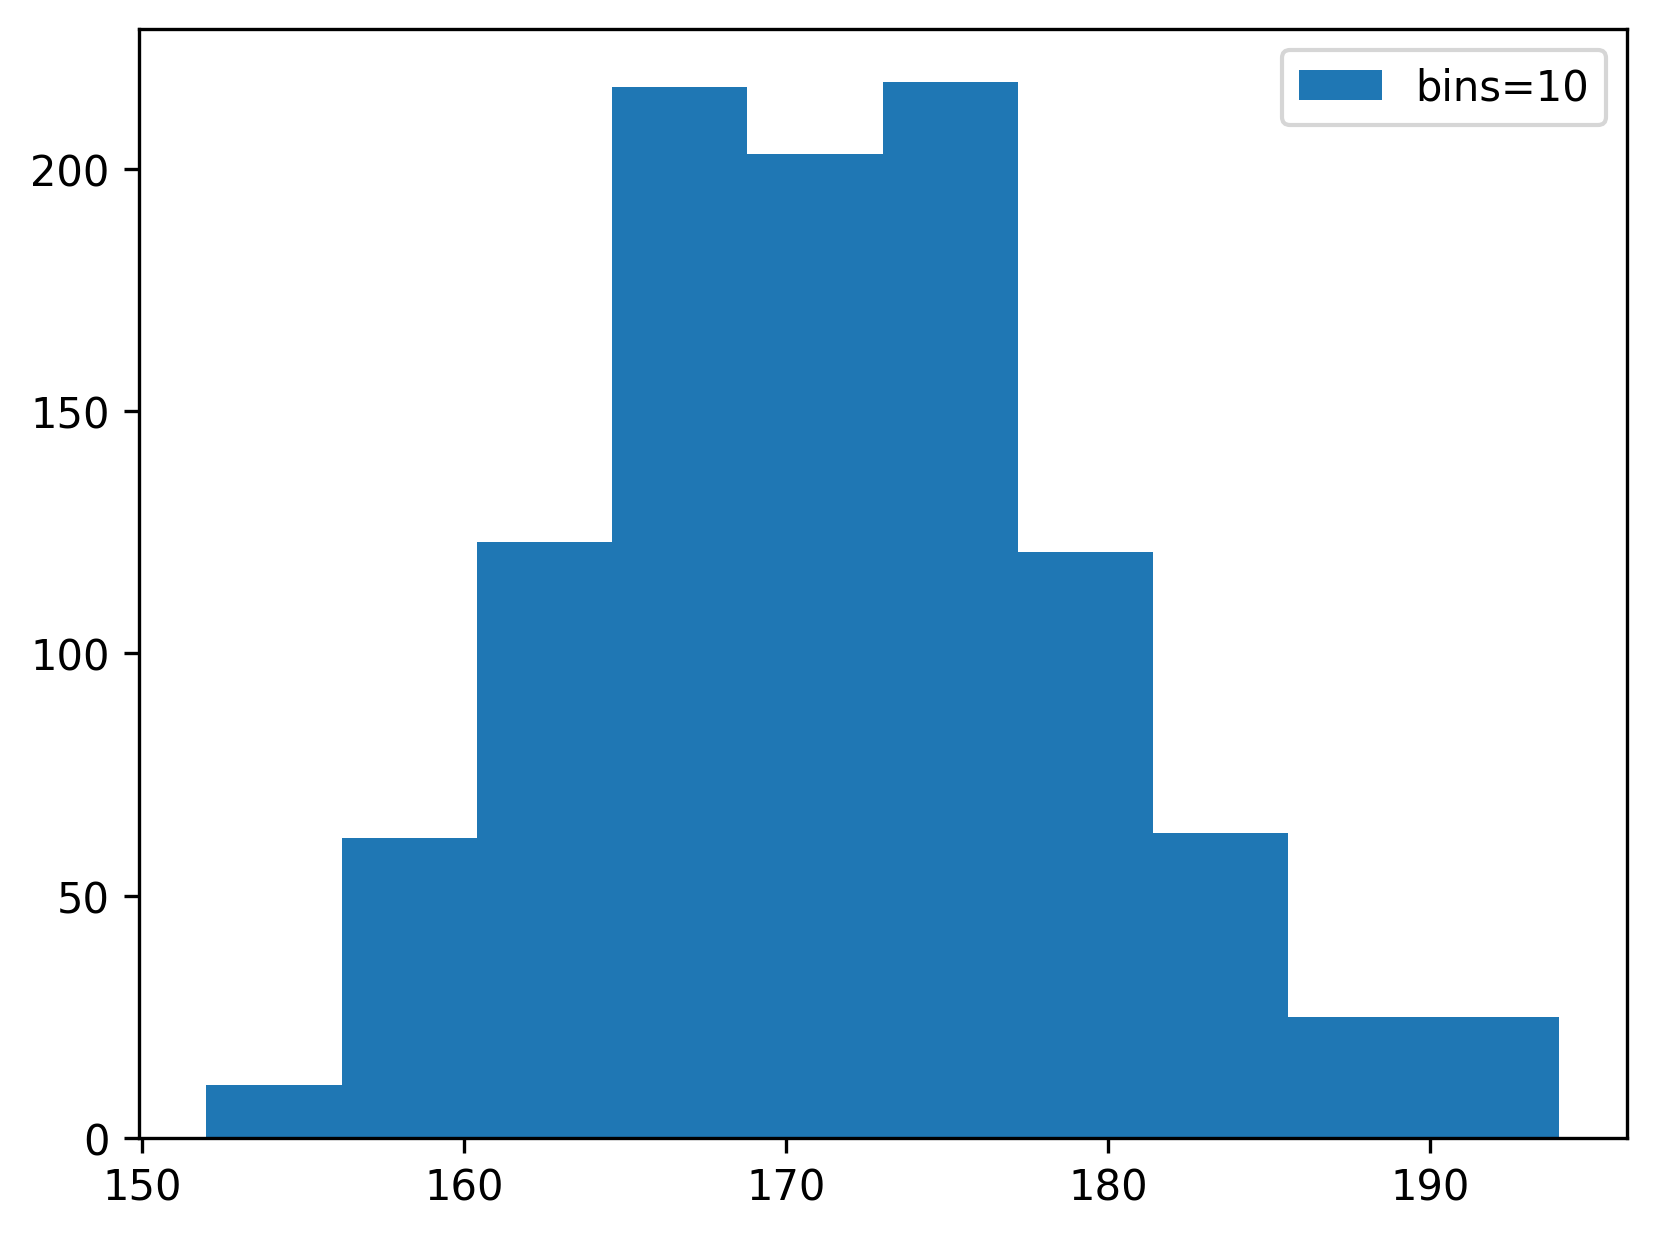

In [6]:
# 기본 히스토그램 시각화

#  신장 컬럼만 필터링
df1 = df[['height_cm']]

# 10cm 단위로 히스토그램 시각화
plt.hist(df1, bins=10, label='bins=10')
plt.legend()
plt.show()

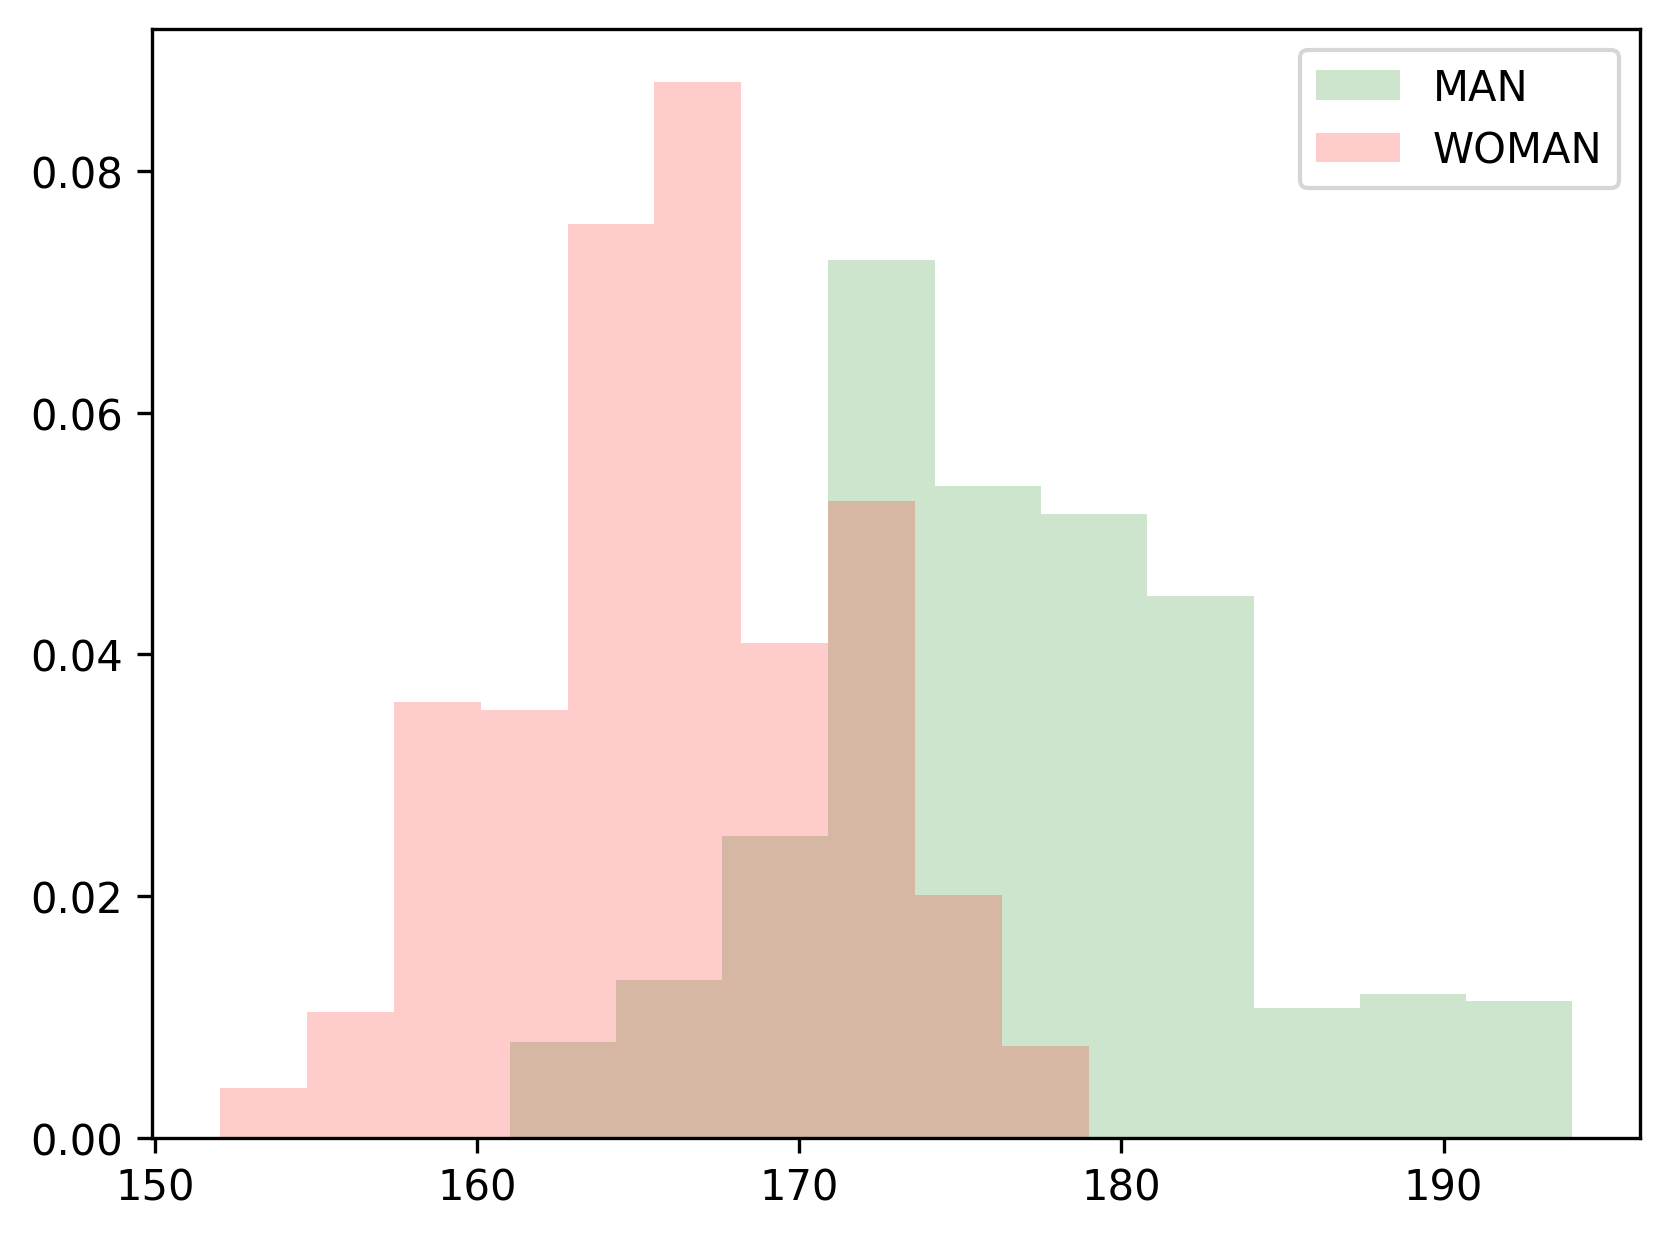

In [7]:
# 남성 여성 히스토그램 시각화

#  남성 여성 별도 데이터셋 생성
df1_1 = df[df['sex'].isin(['man'])]
df1_1 = df1_1[['height_cm']]
df1_2 = df[df['sex'].isin(['woman'])]
df1_2 = df1_2[['height_cm']]

# 10cm 단위로 남성, 여성 신장 히스토그램 시각화
plt.hist(df1_1, color = 'green', alpha = 0.2, bins = 10, label = 'MAN', density = True)
plt.hist(df1_2, color = 'red', alpha = 0.2, bins = 10, label = 'WOMAN', density = True)
plt.legend()
plt.show()

In [32]:
# 파이차트, 도넛차트 시각화를 위한 데이터 전처리

df2 = df[['country','height_cm']]
# 키 175 이상만 추출
df2=df2[df.height_cm >= 175]
df2 = df2.groupby('country').count().reset_index()
df2 = df2.rename(columns={'height_cm': 'height_cm_count'})

df2.head(10)

,country,height_cm_count
0,AUSTRALIA,68
1,DENMARK,59
2,ITALY,67
3,JAPAN,46
4,KOREA,52
5,TURKEY,61


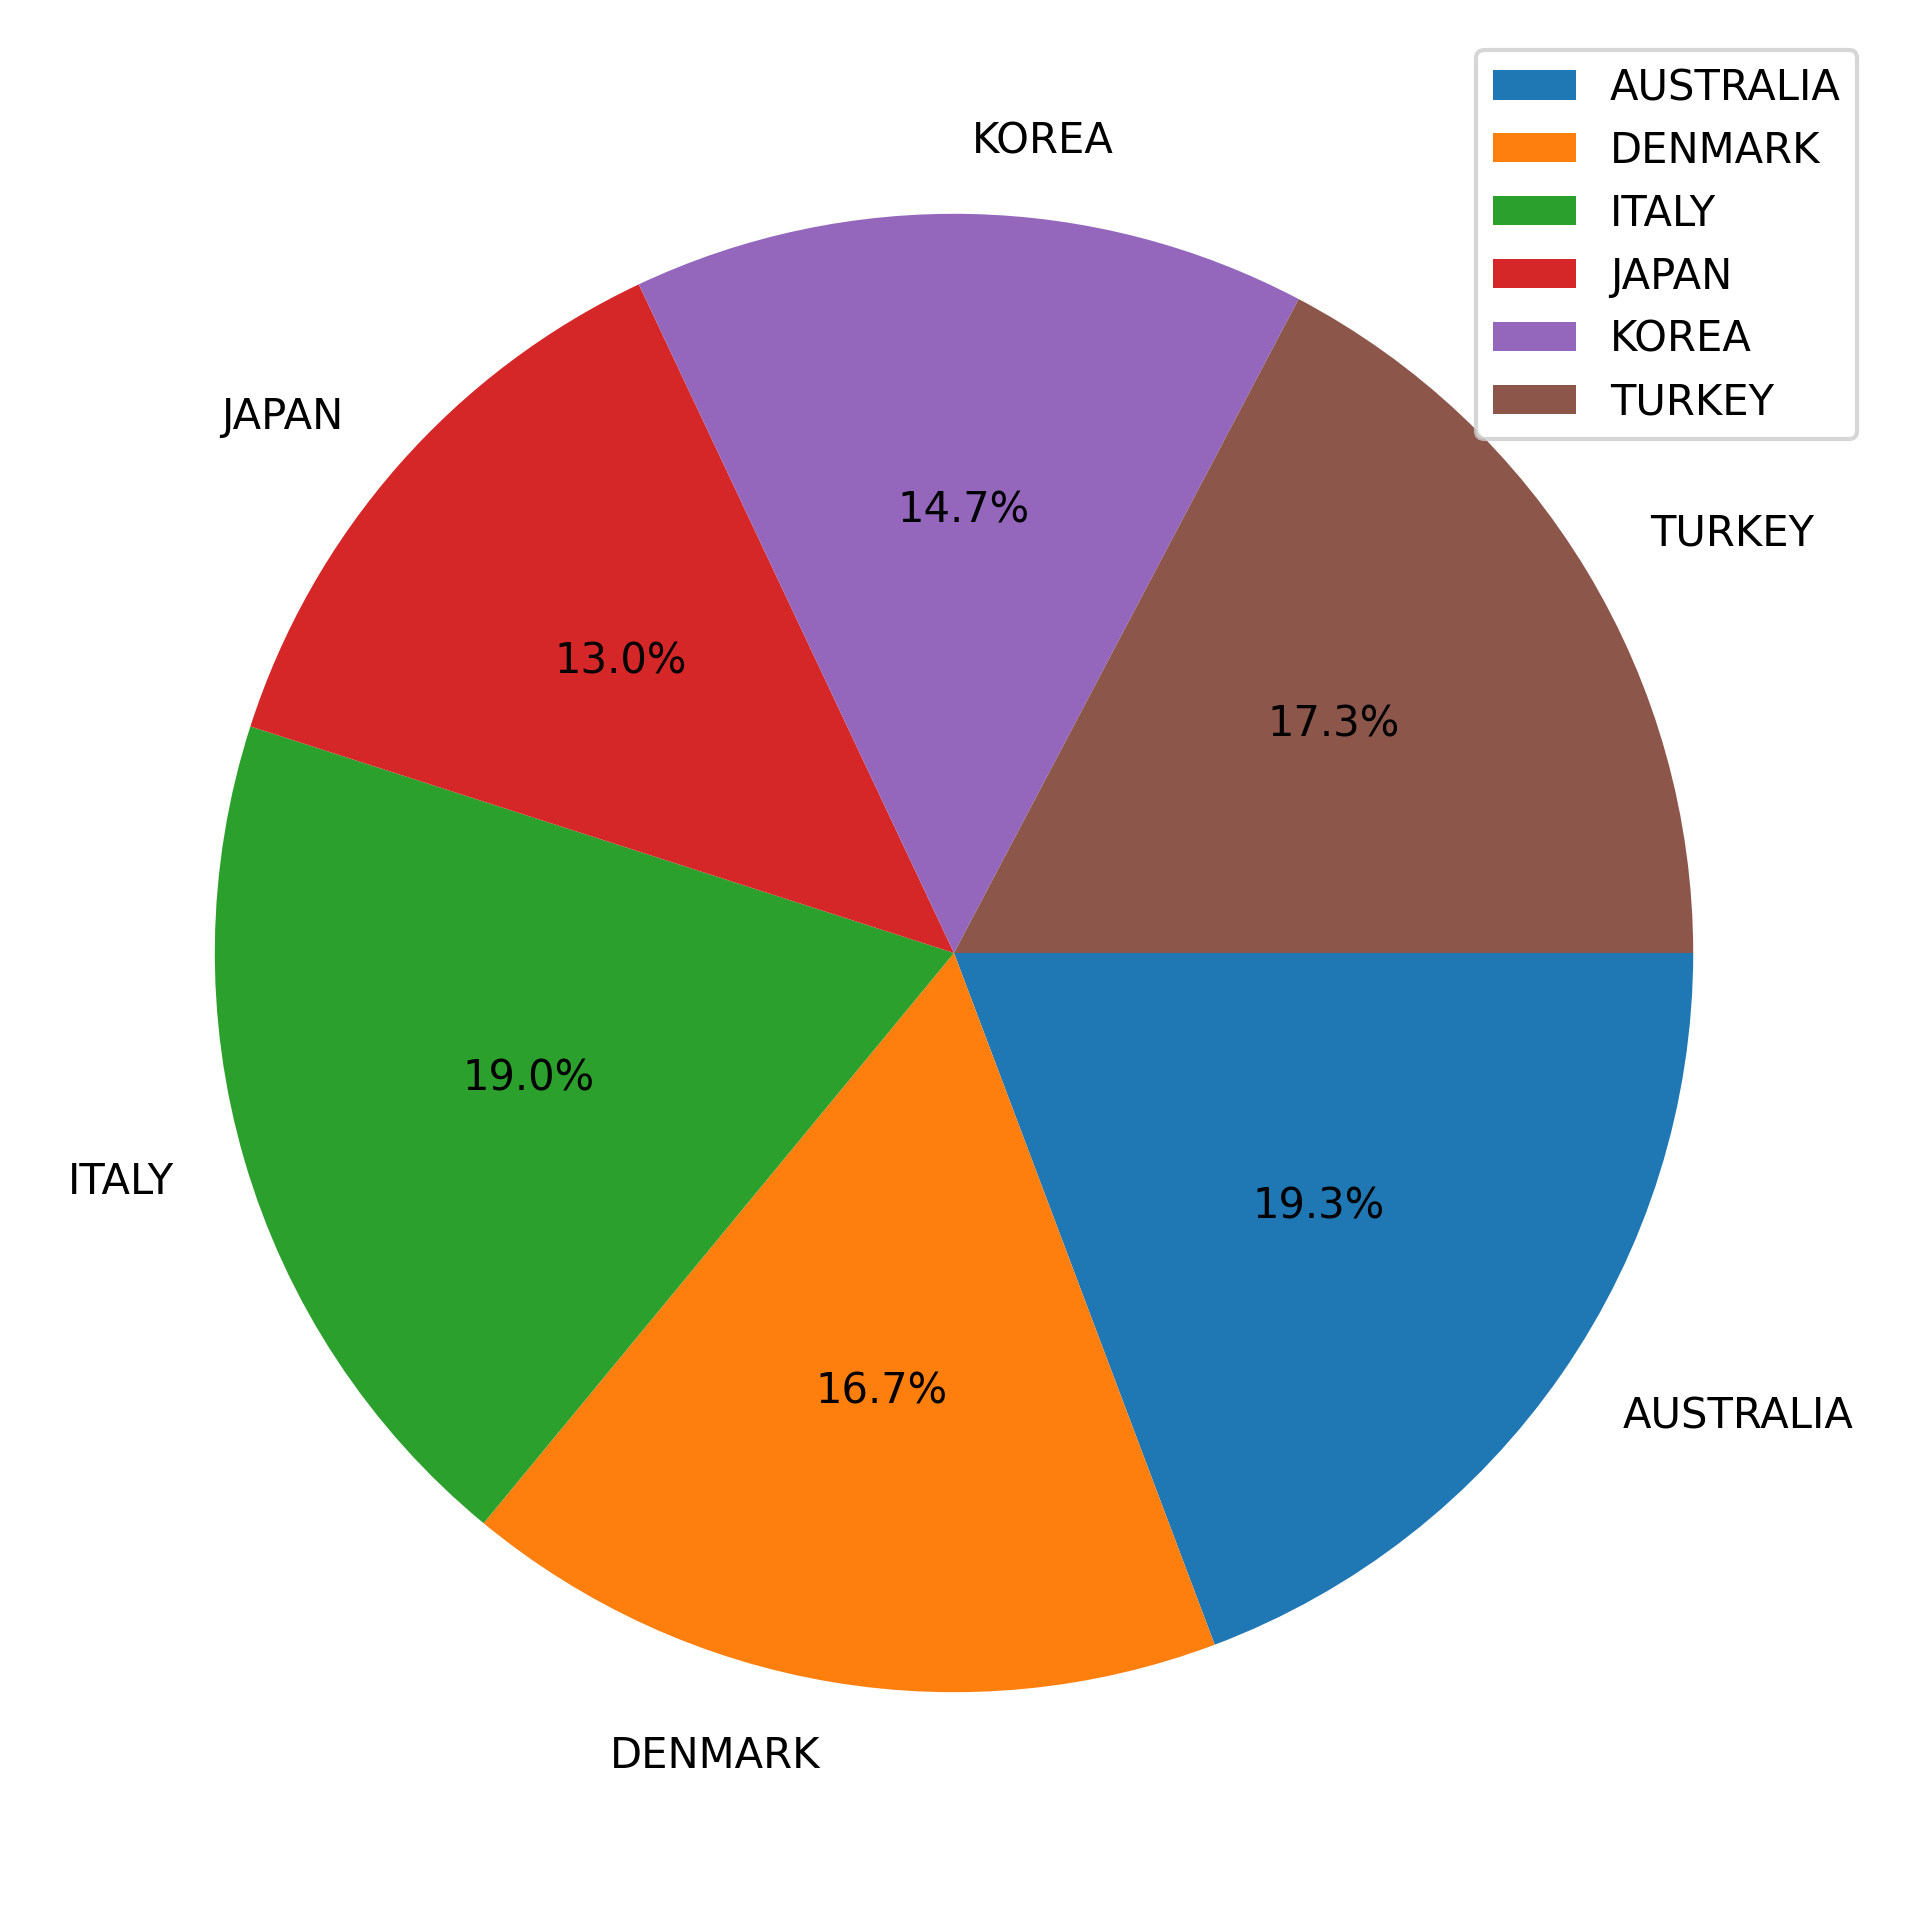

In [33]:
# 파이차트 시각화

fig = plt.figure(figsize=(8,8)) ## 캔버스 생성
fig.set_facecolor('white') ## 캔버스 배경색 설정
ax = fig.add_subplot() # 프레임 생성

# 파이차트 출력
ax.pie(df2.height_cm_count, 
       labels=df2.country, # 라벨 출력
       startangle=0, # 시작점 degree 설정
       counterclock=False, # 시계 방향
       autopct=lambda p : '{:.1f}%'.format(p) # 퍼센자릿수 설정
       )

plt.legend() # 범례 표시
plt.show()

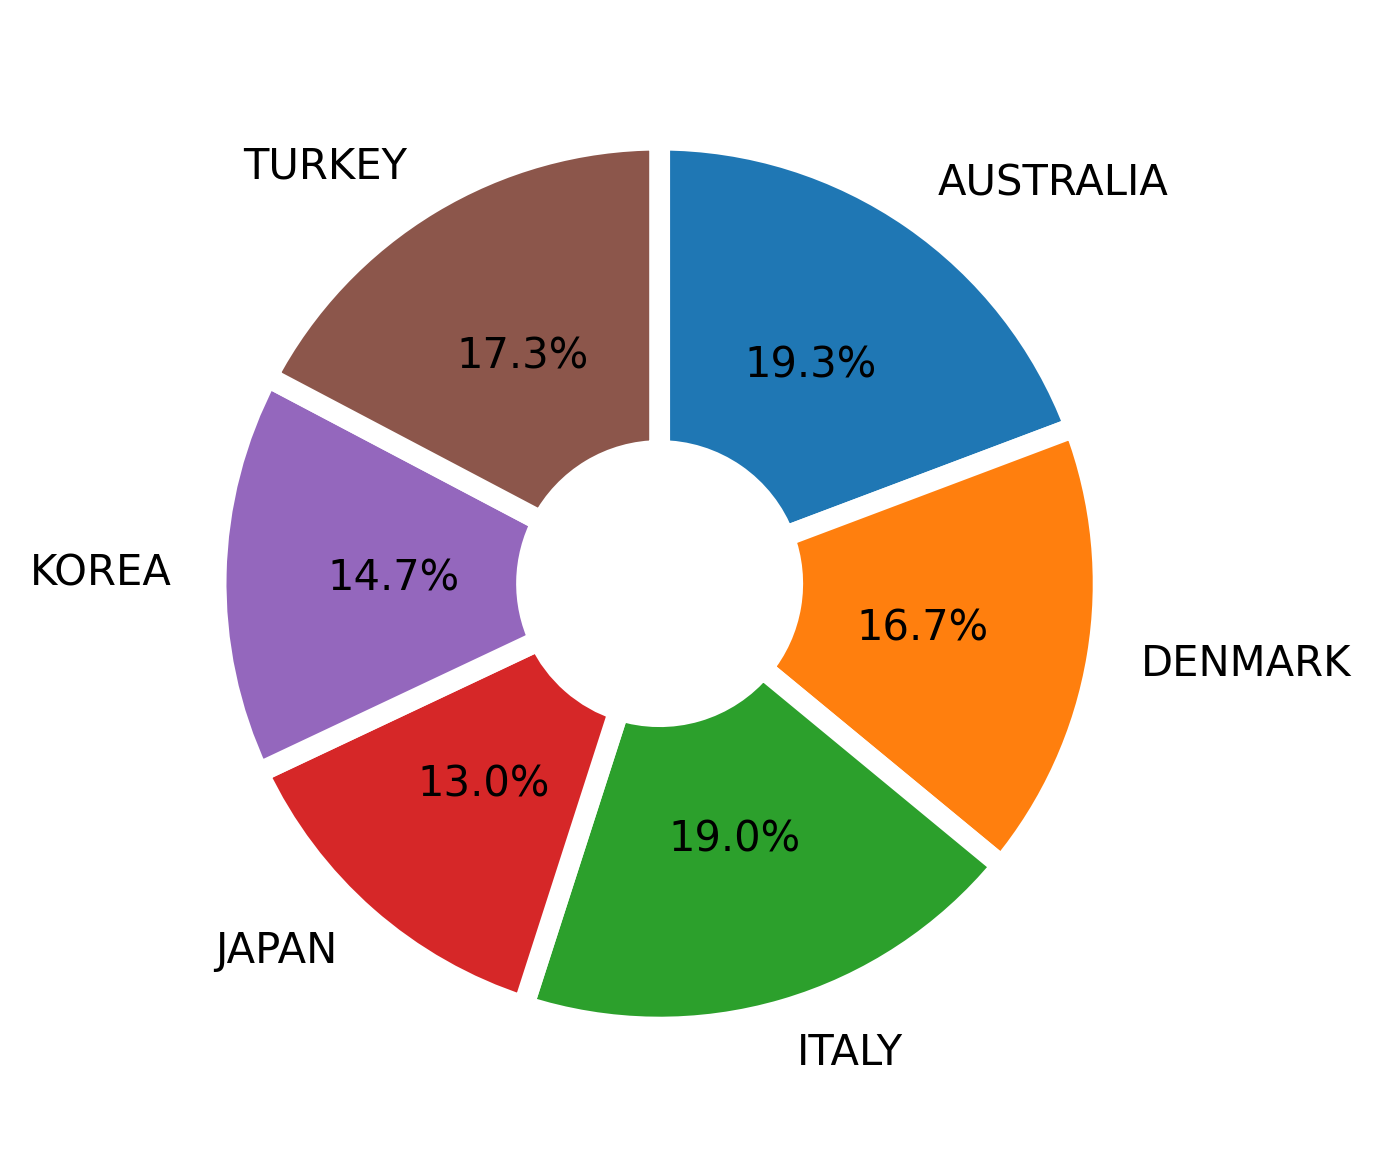

In [34]:
# 도넛차트 시각화

# 차트 형태 옵션 설정
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}

plt.pie(df2.height_cm_count, labels=df2.country, autopct='%.1f%%', 
        startangle=90, counterclock=False, wedgeprops=wedgeprops)
plt.show()

In [35]:
# 트리맵 차트용 데이터셋 전처리

df3 = df[['country', 'sex', 'height_cm']]
df3=df3[df.height_cm >= 175]
# 국가, 성별 단위 신장 175cm 이상 카운팅
df3 = df3.groupby(['country','sex']).count().reset_index()
df3 = df3.rename(columns = {"height_cm":'height_cm_count'})

df3.head(10)

,country,sex,height_cm_count
0,AUSTRALIA,man,59
1,AUSTRALIA,woman,9
2,DENMARK,man,53
3,DENMARK,woman,6
4,ITALY,man,60
5,ITALY,woman,7
6,JAPAN,man,45
7,JAPAN,woman,1
8,KOREA,man,50
9,KOREA,woman,2


In [45]:
# 트리맵 차트 시각화

fig = px.treemap(df3,
                 path=['sex','country'],
                 values='height_cm_count',
                 color='height_cm_count',
                 color_continuous_scale='viridis')

fig.show()

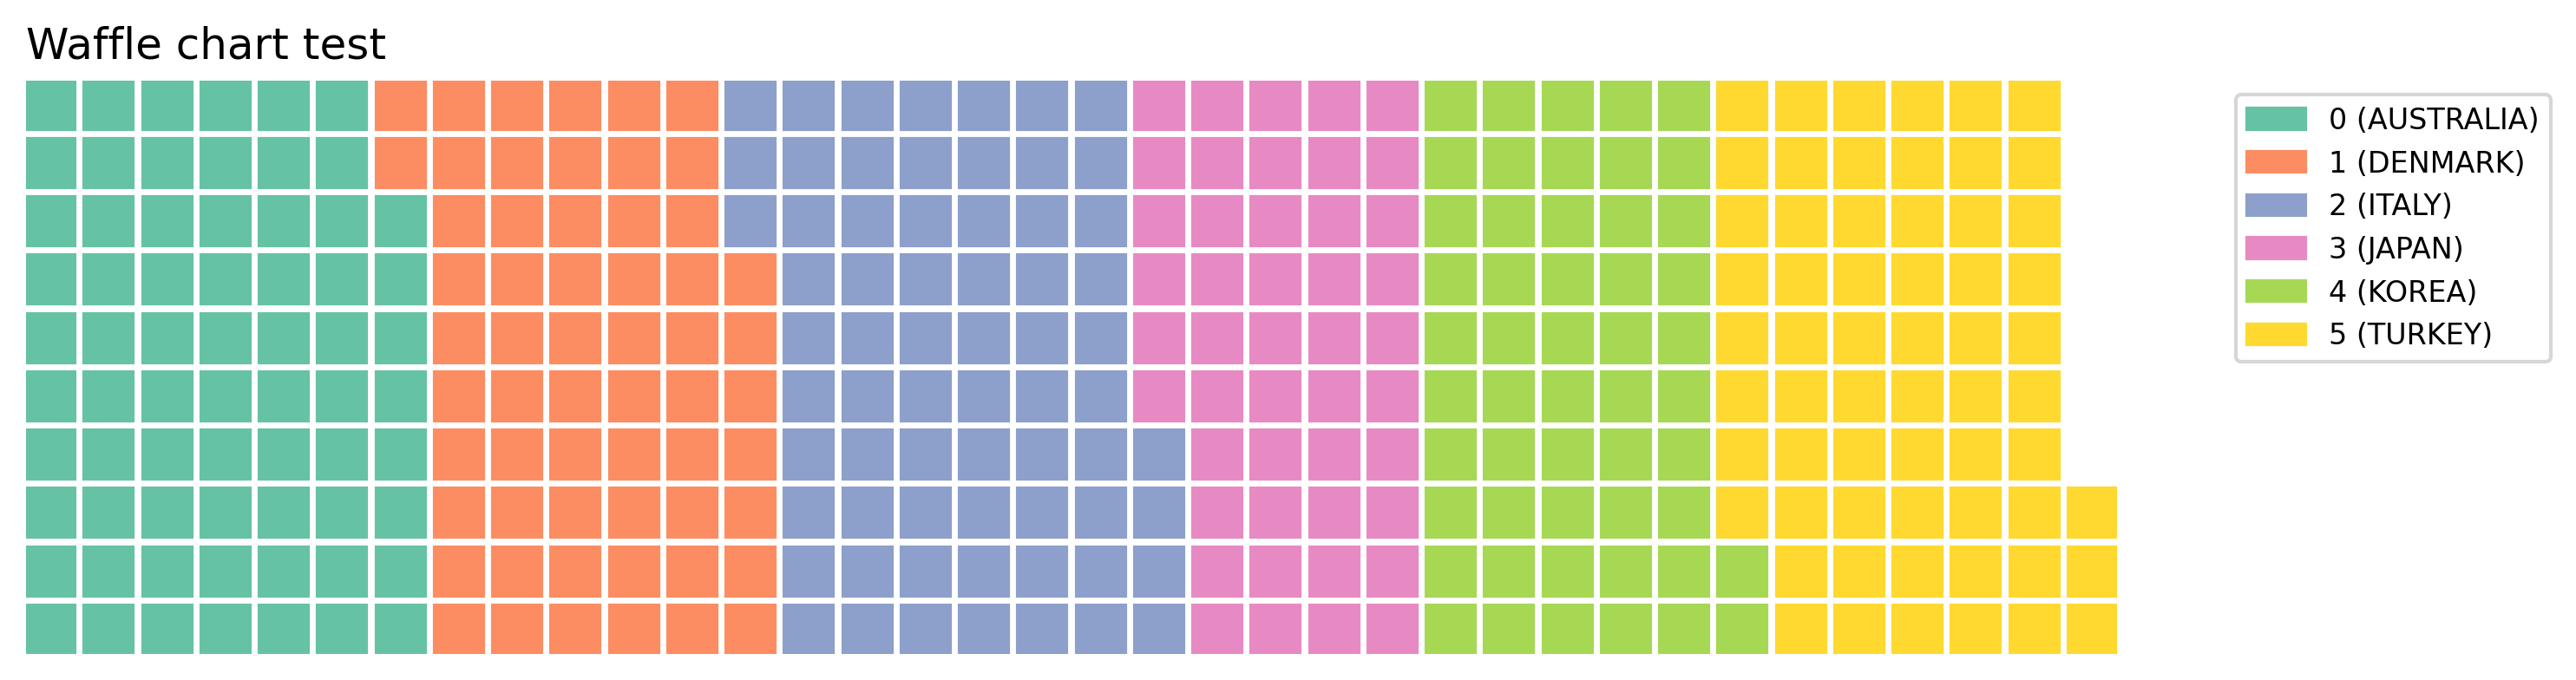

In [46]:
# 와플차트 시각화

fig = plt.figure(
    FigureClass=Waffle,
    plots={
        111: {
            'values': df2['height_cm_count'],
            'labels': ["{0} ({1})".format(n, v) for n, v in df2['country'].items()],
            'legend': {'loc': 'upper left', 'bbox_to_anchor': (1.05, 1), 'fontsize': 8},
            'title': {'label': 'Waffle chart test', 'loc': 'left'}
        }
    },
    rows=10,
    figsize=(10, 10) 
)